# Method 5: Contour Approximation on Skeletonized Image
Uses adaptive mean thresholding + skeletonization to produce clean 1-pixel-wide edges, then applies `cv2.findContours` + `cv2.approxPolyDP` to approximate contour shapes into polygonal line segments.

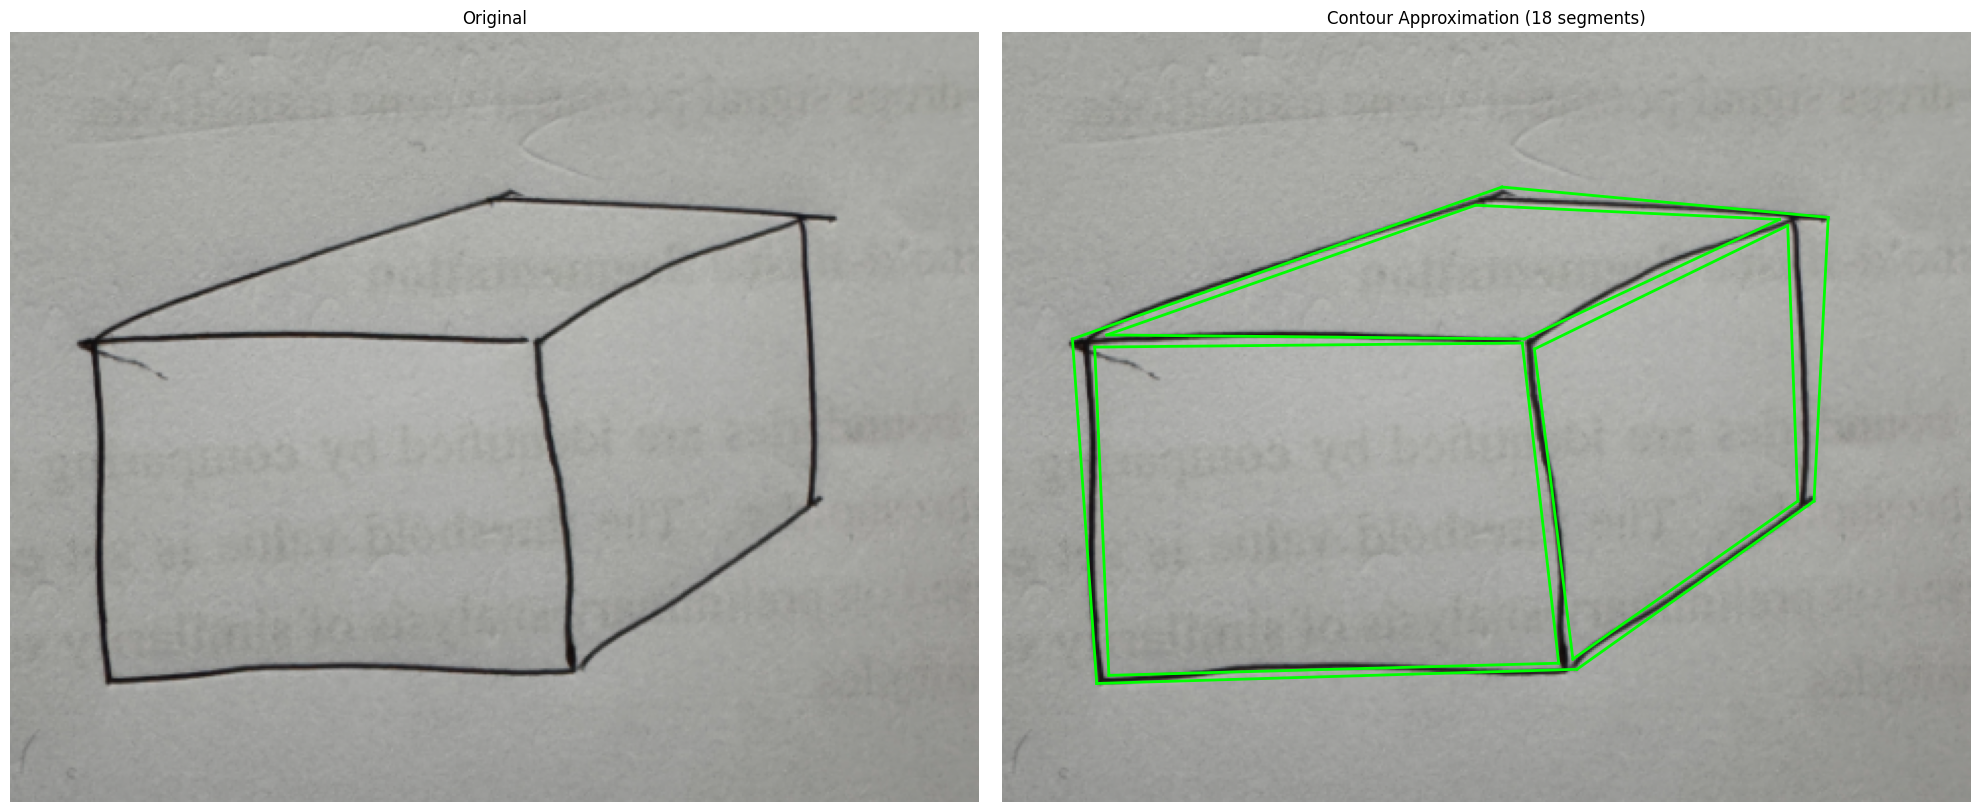

Total polygon segments: 18


In [ ]:
import cv2
import numpy as np
import matplotlib.pyplot as plt
from skimage.morphology import skeletonize

img_color = cv2.imread('cuboid.png')
img_rgb = cv2.cvtColor(img_color, cv2.COLOR_BGR2RGB)
gray = cv2.cvtColor(img_color, cv2.COLOR_BGR2GRAY)
blurred = cv2.GaussianBlur(gray, (5, 5), 1.5)

# Adaptive mean threshold → morph clean → CC filter → skeletonize
binary = cv2.adaptiveThreshold(blurred, 255, cv2.ADAPTIVE_THRESH_MEAN_C,
                               cv2.THRESH_BINARY_INV, 51, 15)
kernel = cv2.getStructuringElement(cv2.MORPH_ELLIPSE, (3, 3))
binary = cv2.morphologyEx(binary, cv2.MORPH_OPEN, kernel, iterations=1)

# Remove small connected components
num_labels, labels, stats, _ = cv2.connectedComponentsWithStats(binary, connectivity=8)
min_area = 200
clean = np.zeros_like(binary)
for i in range(1, num_labels):
    if stats[i, cv2.CC_STAT_AREA] >= min_area:
        clean[labels == i] = 255

# Skeletonize to 1-pixel-wide lines
skeleton = skeletonize(clean > 0).astype(np.uint8) * 255

# Find contours on skeleton
contours, _ = cv2.findContours(skeleton, cv2.RETR_LIST, cv2.CHAIN_APPROX_SIMPLE)

fig, axes = plt.subplots(1, 3, figsize=(24, 8))
axes[0].imshow(img_rgb); axes[0].set_title('Original'); axes[0].axis('off')
axes[1].imshow(skeleton, cmap='gray'); axes[1].set_title('Skeleton'); axes[1].axis('off')
axes[2].imshow(img_rgb)
axes[2].axis('off')

# Approximate each contour with a polygon and draw edges
min_contour_length = 30
total_segments = 0
for cnt in contours:
    if cv2.arcLength(cnt, True) < min_contour_length:
        continue
    epsilon = 0.015 * cv2.arcLength(cnt, True)
    approx = cv2.approxPolyDP(cnt, epsilon, True)
    pts = approx.reshape(-1, 2)
    for k in range(len(pts)):
        x1, y1 = pts[k]
        x2, y2 = pts[(k + 1) % len(pts)]
        seg_len = np.hypot(x2 - x1, y2 - y1)
        if seg_len >= 15:  # skip tiny closing segments
            axes[2].plot([x1, x2], [y1, y2], color='lime', linewidth=2)
            total_segments += 1

axes[2].set_title(f'Contour Approx on Skeleton ({total_segments} segments)')
plt.tight_layout()
fig.savefig('result_contour_approx.png', dpi=150, bbox_inches='tight')
plt.show()
print(f'Total polygon segments: {total_segments}')